## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
fatal: unable to access 'https://github.com/Lv1g1/RecSys-Challenge-2025.git/': Could not resolve host: github.com


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os
import pandas as pd
from xgboost import XGBRanker
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import generate_submission, load_xgboost_cv_folds, XGBOOST_DATAFRAMES
from Challenge.utils import XGBoostRerankerRecommender

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
_, URM_outer, _ = load_xgboost_cv_folds()
del _

In [5]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

X_train = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_train

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_data.parquet


,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,6411,False,0.081851,717,0,0.701361,5,1,0.681310,...,407.142853,1399.072754,4.281490,18.897297,0.447156,0.278489,-1.061027,3.246427,80,874
1,0,2168,False,0.078760,750,0,0.540989,40,0,0.491260,...,358.047607,936.414124,3.650616,14.062557,0.333984,0.222666,0.733968,1.210770,80,841
2,0,6098,True,0.082225,713,0,0.708915,3,1,0.740307,...,124.571426,279.955811,2.169494,3.165847,0.503251,0.205144,0.271329,0.168902,80,878
3,0,3049,False,0.128114,412,0,0.693846,6,1,0.457670,...,321.095245,918.941772,4.353480,19.441338,0.310892,0.245103,0.985542,0.890398,80,1368
4,0,2399,False,0.442124,27,0,0.639774,15,1,0.261722,...,362.523804,1433.629395,4.515592,20.544024,0.405237,0.275703,-1.123605,4.698762,80,4721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756433,27094,4180,False,0.367297,48,0,0.042708,2024,0,0.000000,...,3173.142822,2376.120117,0.292561,-1.572491,0.066819,0.232602,3.163013,11.877620,250,3922
3756434,27094,3236,False,0.593651,8,1,0.194622,524,0,0.114155,...,2111.714355,2253.487793,1.051186,-0.458617,0.134725,0.246047,2.432874,6.639362,250,6339
3756435,27094,4615,False,0.004402,4126,0,0.144729,767,0,0.037827,...,1697.571411,1721.538208,1.812891,2.658815,0.099026,0.205823,2.965396,11.336728,250,47
3756436,27094,6584,False,0.412343,31,0,0.112825,1005,0,0.000000,...,2309.666748,1955.347290,0.944244,-0.389569,0.105150,0.219539,3.446590,12.917460,250,4403


In [6]:
if not X_train['UserID'].is_monotonic_increasing:
    print("⚠️ Data is NOT sorted by UserID.")
    print("Sorting and overwriting file for future efficiency...")
    
    # Sort and reset index (critical for contiguous memory in ML)
    X_train = X_train.sort_values(by='UserID').reset_index(drop=True)
    
    # Overwrite the file on disk
    X_train.to_parquet(
        path=file_path,
        engine='fastparquet',
        compression='zstd',
        index=False
    )
    
    print(f"✅ Data sorted and saved to {file_path}")

In [7]:
assert X_train['UserID'].is_monotonic_increasing, "UserID column is not sorted in increasing order!"

# Group Calculation
groups = X_train.groupby("UserID").size().values

# Target and Feature Matrix Definition
y_train = X_train["Label"]

# Drop the identifiers (UserID, ItemID) and the target (Label), keeping only the features
X_train = X_train.drop(columns=["Label", "UserID", "ItemID"], errors='ignore') 

assert groups.sum() == X_train.shape[0], "Group sum does not match total data size!"

## **Train XG Boost**

In [8]:
# Hyperparameters (Your baseline configuration)
n_estimators = 50
learning_rate = 1e-1
reg_alpha = 1e-1
reg_lambda = 1e-1
max_depth = 5
grow_policy = "depthwise"
objective = "pairwise" 

XGB_model = XGBRanker(objective='rank:{}'.format(objective),
                      n_estimators = int(n_estimators),
                      random_state = 42, # Fixed seed for reproducibility
                      learning_rate = learning_rate,
                      reg_alpha = reg_alpha,
                      reg_lambda = reg_lambda,
                      max_depth = int(max_depth),
                      max_leaves = 0,
                      grow_policy = grow_policy,
                      verbosity = 1, # Set to 1 to see training progress
                      booster = "gbtree",
                      n_jobs=-1 # Use all cores
                      )

In [9]:
print(f"Starting XGBRanker training with {len(groups)} user groups...")

XGB_model.fit(X_train,
              y_train,
              group=groups,
              verbose=True)

Starting XGBRanker training with 27095 user groups...


,objective,'rank:pairwise'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(X_train)
auc_score = roc_auc_score(y_train, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7845


## **Plots**

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

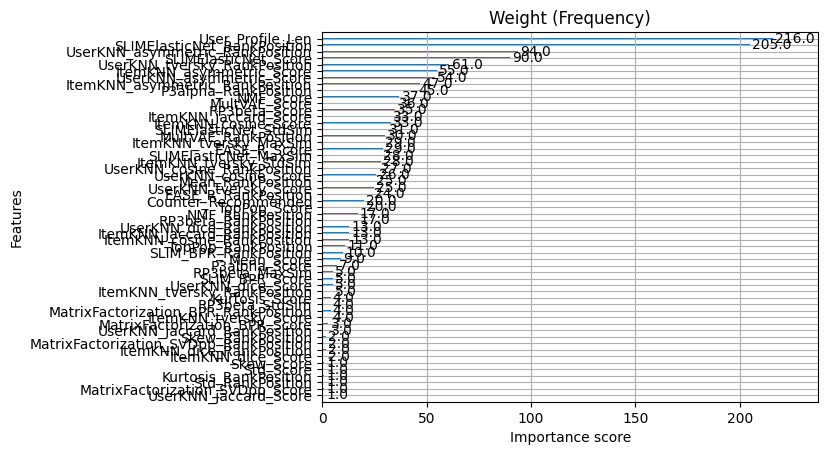

In [11]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

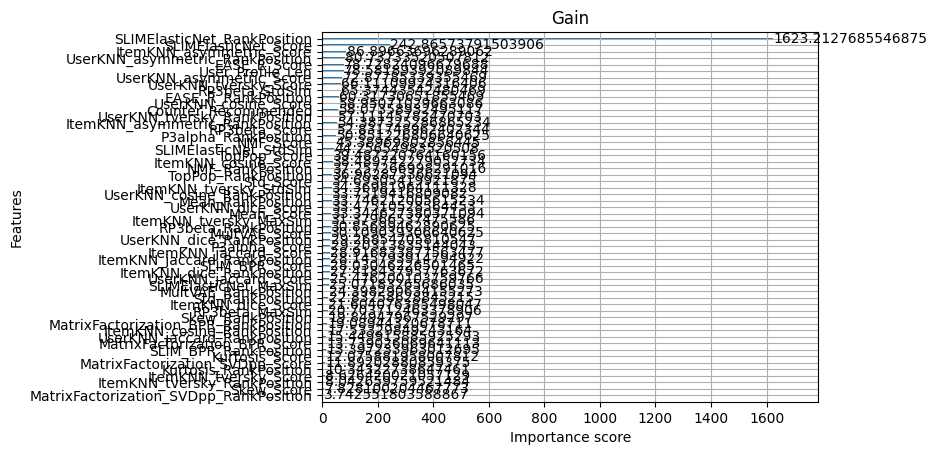

In [12]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

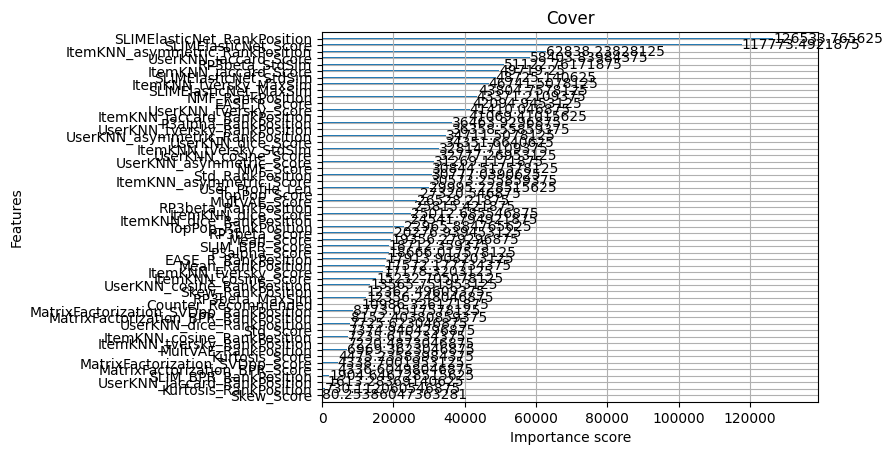

In [13]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

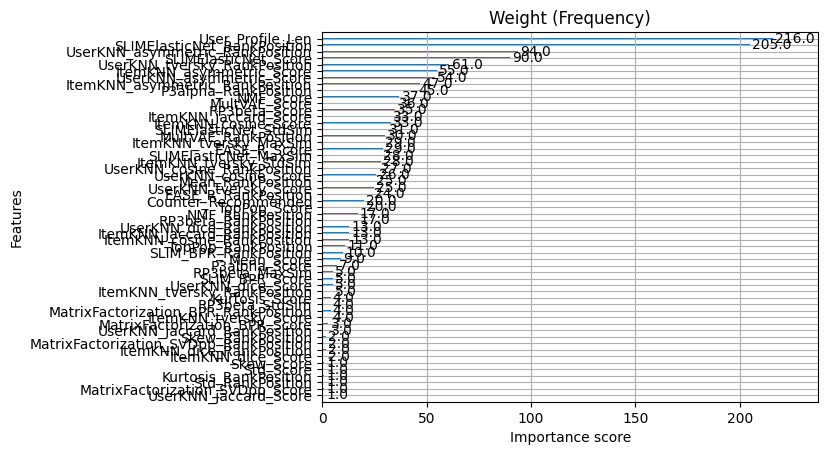

In [14]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

## **Make prediction**

In [15]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "prediction_data.parquet")

X_pred = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_pred

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/prediction_data.parquet


,UserID,ItemID,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,ItemKNN_jaccard_RankPosition,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,6054,0.149410,318,0,0.238791,446,0,0.275156,65,...,792.619019,1259.735596,3.424178,13.648808,0.155094,0.222226,2.062433,8.472574,96,1987
1,0,5705,0.228137,151,0,0.297280,285,0,0.192252,135,...,517.857117,1002.365845,3.909873,16.645828,0.221487,0.212462,1.968379,7.094590,96,3034
2,0,6022,0.044515,1248,0,0.317602,244,0,0.188949,144,...,731.095215,1318.600464,3.875400,16.406370,0.172204,0.239770,1.265970,5.161270,96,592
3,0,4349,0.014061,2542,0,0.186696,629,0,0.097078,326,...,940.571411,1462.672119,2.236995,4.635228,0.155703,0.187391,2.532954,8.595733,96,187
4,0,5723,0.279645,99,0,0.437175,102,0,0.575141,12,...,406.047607,989.302856,3.682582,14.145194,0.284984,0.233453,1.027589,1.420211,96,3719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3807584,27094,2779,0.373186,44,0,0.000000,5919,0,0.000000,5843,...,2485.571533,2221.112793,0.821142,-0.875797,0.086936,0.229149,3.043848,11.408940,314,4963
3807585,27094,1339,0.528310,13,1,0.426378,96,0,0.382425,35,...,868.761902,1373.918823,1.627563,0.853245,0.272436,0.238561,1.084918,1.989917,314,7026
3807586,27094,5599,0.006166,3470,0,0.244005,376,0,0.114904,291,...,768.952393,1087.479858,2.089986,3.035373,0.192299,0.197321,2.571045,7.672733,314,82
3807587,27094,3767,0.166704,249,0,0.422187,101,0,0.251825,87,...,362.714294,986.927429,4.447657,20.083519,0.282693,0.215985,1.504674,4.420769,314,2217


In [16]:
# Instantiate the recommender with the trained XGB model
recommender = XGBoostRerankerRecommender(
    XGB_model=XGB_model,
    df=X_pred
)

In [18]:
generate_submission(recommender, "xg_boost_baseline_v1.csv")